# Risky Debt Nested VFI Backend Benchmark

Compare the NumPy reference nested VFI solver and the TF-native blocked nested VFI solver on the same risky-debt benchmark.

In [1]:
import json
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _REPO_ROOT = Path(_nb_file).parent.parent
else:
    _REPO_ROOT = Path.cwd().parent
sys.path.insert(0, str(_REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

from src.v2.evaluation import (
    prepare_evaluation_run,
    save_figure,
    save_manifest_sections,
    save_solver_bundle,
)
from src.v2.environments.risky_debt import EconomicParams, RiskyDebtEnv, ShockParams
from src.v2.solvers import (
    NestedVFIConfig,
    NestedVFIGridConfig,
    NestedVFITFRuntimeConfig,
    solve_nested_vfi,
    solve_nested_vfi_tf,
)

print(f"TF version: {tf.__version__}")
print(f"Physical GPUs: {tf.config.list_physical_devices('GPU')}")


TF version: 2.16.2
Physical GPUs: []


In [2]:
EXPERIMENT_NAME = "risky_debt_nested_vfi_backend_compare"

_nb_file = globals().get("__vsc_ipynb_file__")
if _nb_file:
    _repo_root = Path(_nb_file).parent.parent
else:
    _repo_root = Path.cwd().parent

RUN = prepare_evaluation_run(
    EXPERIMENT_NAME,
    save_run=True,
    results_root=str(_repo_root / "outputs" / "notebooks"),
)
print(f"Run dir: {RUN['run_dir']}")

PROFILE = "FAST_DEBUG"
_PROFILES = {
    "FAST_DEBUG": dict(
        EXO=10,
        ENDO_K=20,
        ENDO_B=20,
        MAX_INNER=50,
        MAX_OUTER=5,
        TOL_INNER=1e-6,
        TOL_OUTER_VALUE=1e-4,
    ),
    "FULL": dict(
        EXO=50,
        ENDO_K=50,
        ENDO_B=50,
        MAX_INNER=1000,
        MAX_OUTER=500,
        TOL_INNER=1e-6,
        TOL_OUTER_VALUE=1e-6,
    ),
}
P = _PROFILES[PROFILE]

def make_env():
    return RiskyDebtEnv(
        econ_params=EconomicParams(
            interest_rate=0.04,
            depreciation_rate=0.15,
            production_elasticity=0.7,
            cost_convex=0.01,
            tax=0.35,
            default_haircut=0.7,
            cost_inject_fixed=0.1,
            cost_inject_linear=0.05,
        ),
        shock_params=ShockParams(mu=0.0, rho=0.7, sigma=0.15),
        k_min_mult=0.01,
        k_max_mult=1.5,
        b_max_mult=5.0,
        b_min_mult=0.2,
    )

config = NestedVFIConfig(
    grid=NestedVFIGridConfig(
        exo_sizes=[P["EXO"]],
        endo_sizes=[P["ENDO_K"], P["ENDO_B"]],
        exo_spacings=["log"],
        endo_spacings=["geometric", "linear"],
    ),
    max_iter_inner=P["MAX_INNER"],
    tol_inner=P["TOL_INNER"],
    max_iter_outer=P["MAX_OUTER"],
    tol_outer_value=P["TOL_OUTER_VALUE"],
)

tf_runtime = NestedVFITFRuntimeConfig(
    dtype="float32",
    choice_block_size=128,
    jit_compile=True,
    device=None,
    record_inner_history=False,
)

save_manifest_sections(
    RUN,
    profile=PROFILE,
    solver_config={
        "exo_sizes": config.grid.exo_sizes,
        "endo_sizes": config.grid.endo_sizes,
        "exo_spacings": config.grid.exo_spacings,
        "endo_spacings": config.grid.endo_spacings,
        "max_iter_inner": config.max_iter_inner,
        "max_iter_outer": config.max_iter_outer,
        "tol_inner": config.tol_inner,
        "tol_outer_value": config.tol_outer_value,
    },
    tf_runtime_config={
        "dtype": tf_runtime.dtype,
        "choice_block_size": tf_runtime.choice_block_size,
        "jit_compile": tf_runtime.jit_compile,
        "device": tf_runtime.device,
        "record_inner_history": tf_runtime.record_inner_history,
    },
)

print(f"Profile: {PROFILE}")
print(f"Grid: z={P['EXO']} x k={P['ENDO_K']} x b={P['ENDO_B']}")
print(f"Grid spacing: z={config.grid.exo_spacings[0]}, k={config.grid.endo_spacings[0]}, b={config.grid.endo_spacings[1]}")


Run dir: /Users/wangzhaoxuan/Desktop/JPM-TSRL/DL_corp_finance/outputs/notebooks/risky_debt_nested_vfi_backend_compare/20260327-190943
Profile: FAST_DEBUG
Grid: z=10 x k=20 x b=20
Grid spacing: z=log, k=geometric, b=linear


In [3]:
def _to_numpy(x):
    if hasattr(x, "numpy"):
        return x.numpy()
    return np.asarray(x)

def _sync_result(result):
    _ = float(np.sum(_to_numpy(result["value"])))

def _discount_grid(r_tilde):
    return np.where(np.isfinite(r_tilde), 1.0 / np.maximum(1.0 + r_tilde, 1e-12), 0.0)

def _run_backend(label, solve_fn, *, runtime_config=None):
    env = make_env()
    t0 = time.perf_counter()
    if runtime_config is None:
        result = solve_fn(env, config=config)
    else:
        result = solve_fn(env, config=config, runtime_config=runtime_config)
    _sync_result(result)
    wall_time = time.perf_counter() - t0
    return env, result, wall_time

def _comparison_row(label, result, wall_time, ref_result=None, *, compile_mode, block_size):
    row = {
        "label": label,
        "backend": result["backend"],
        "dtype": result["dtype"],
        "device": result["device"],
        "compile_mode": compile_mode,
        "choice_block_size": block_size,
        "wall_time_sec": float(wall_time),
        "stop_reason": result["stop_reason"],
        "n_outer": int(result["n_outer"]),
        "n_inner_last": int(result["n_inner_last"]),
        "default_fraction": float(np.mean(_to_numpy(result["default_mask"]))),
        "max_funded_residual": float(np.nanmax(np.abs(_to_numpy(result["zero_profit_residual"])[_to_numpy(result["funded_mask"])]))),
    }
    if ref_result is None:
        row["value_gap_vs_numpy"] = 0.0
        row["policy_gap_vs_numpy"] = 0.0
        row["pricing_gap_vs_numpy"] = 0.0
    else:
        row["value_gap_vs_numpy"] = float(np.max(np.abs(_to_numpy(result["value"]) - _to_numpy(ref_result["value"]))))
        row["policy_gap_vs_numpy"] = float(np.max(np.abs(_to_numpy(result["policy_endo"]) - _to_numpy(ref_result["policy_endo"]))))
        row["pricing_gap_vs_numpy"] = float(np.max(np.abs(_discount_grid(_to_numpy(result["r_tilde_grid"])) - _discount_grid(_to_numpy(ref_result["r_tilde_grid"])))) )
    return row


In [4]:
numpy_env, numpy_result, numpy_wall = _run_backend("numpy", solve_nested_vfi)
tf_env_cold, tf_result_cold, tf_wall_cold = _run_backend(
    "tf_cold",
    solve_nested_vfi_tf,
    runtime_config=tf_runtime,
)
tf_env_warm, tf_result_warm, tf_wall_warm = _run_backend(
    "tf_warm",
    solve_nested_vfi_tf,
    runtime_config=tf_runtime,
)

comparison_rows = [
    _comparison_row(
        "NumPy",
        numpy_result,
        numpy_wall,
        ref_result=None,
        compile_mode="n/a",
        block_size="n/a",
    ),
    _comparison_row(
        "TF cold",
        tf_result_cold,
        tf_wall_cold,
        ref_result=numpy_result,
        compile_mode="cold",
        block_size=tf_runtime.choice_block_size,
    ),
    _comparison_row(
        "TF warm",
        tf_result_warm,
        tf_wall_warm,
        ref_result=numpy_result,
        compile_mode="warm",
        block_size=tf_runtime.choice_block_size,
    ),
]

save_solver_bundle(
    RUN,
    numpy_result,
    summary=comparison_rows[0],
    name="nested_vfi_numpy",
)
save_solver_bundle(
    RUN,
    tf_result_cold,
    summary=comparison_rows[1],
    name="nested_vfi_tf_cold",
)
save_solver_bundle(
    RUN,
    tf_result_warm,
    summary=comparison_rows[2],
    name="nested_vfi_tf_warm",
)
save_manifest_sections(RUN, comparison_rows=comparison_rows)

print(json.dumps(comparison_rows, indent=2))


Nested VFI outer=  0 | inner=converged (26 iters, diff=6.73e-07) | outer_value_diff=4.82 | pricing_diff=0.96
Nested VFI outer=  1 | inner=converged (27 iters, diff=7.02e-07) | outer_value_diff=5.34 | pricing_diff=0.96
Nested VFI outer=  2 | inner=converged (28 iters, diff=5.24e-07) | outer_value_diff=4.65 | pricing_diff=0.96
Nested VFI outer=  3 | inner=converged (22 iters, diff=9.20e-07) | outer_value_diff=5.24 | pricing_diff=0.96
Nested VFI outer=  4 | inner=converged (28 iters, diff=7.33e-07) | outer_value_diff=4.16 | pricing_diff=0.96


I0000 00:00:1774663784.778491 6720705 service.cc:145] XLA service 0x12d65ef30 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774663784.778532 6720705 service.cc:153]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1774663784.989486 6720705 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Nested VFI TF outer=  0 | inner=converged (28 iters, diff=0.00e+00) | outer_value_diff=4.82 | pricing_diff=0.96
Nested VFI TF outer=  1 | inner=converged (26 iters, diff=0.00e+00) | outer_value_diff=5.34 | pricing_diff=0.96
Nested VFI TF outer=  2 | inner=converged (28 iters, diff=0.00e+00) | outer_value_diff=4.65 | pricing_diff=0.96
Nested VFI TF outer=  3 | inner=converged (25 iters, diff=0.00e+00) | outer_value_diff=5.24 | pricing_diff=0.96
Nested VFI TF outer=  4 | inner=converged (30 iters, diff=0.00e+00) | outer_value_diff=4.16 | pricing_diff=0.96
Nested VFI TF outer=  0 | inner=converged (28 iters, diff=0.00e+00) | outer_value_diff=4.82 | pricing_diff=0.96
Nested VFI TF outer=  1 | inner=converged (26 iters, diff=0.00e+00) | outer_value_diff=5.34 | pricing_diff=0.96
Nested VFI TF outer=  2 | inner=converged (28 iters, diff=0.00e+00) | outer_value_diff=4.65 | pricing_diff=0.96
Nested VFI TF outer=  3 | inner=converged (25 iters, diff=0.00e+00) | outer_value_diff=5.24 | pricing_di

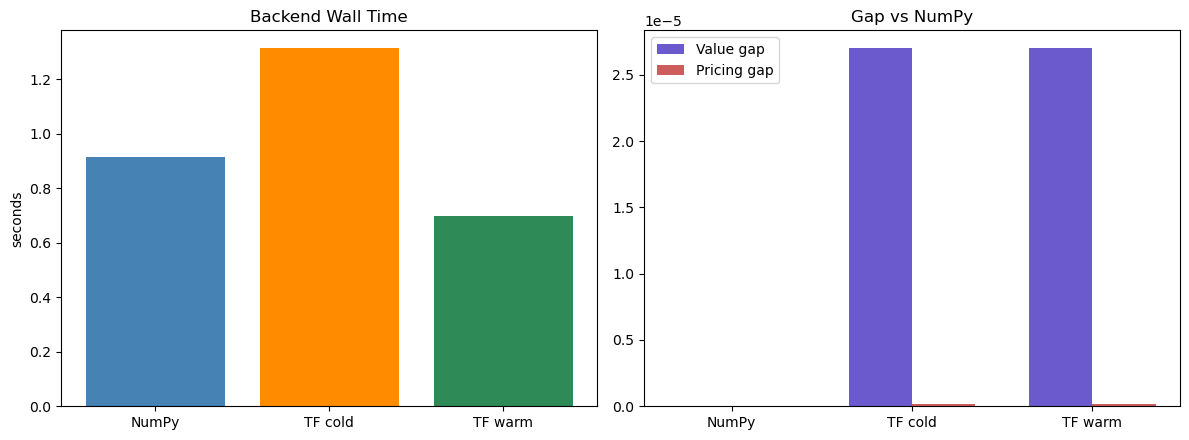

In [5]:
labels = [row["label"] for row in comparison_rows]
wall_times = [row["wall_time_sec"] for row in comparison_rows]
value_gaps = [row["value_gap_vs_numpy"] for row in comparison_rows]
pricing_gaps = [row["pricing_gap_vs_numpy"] for row in comparison_rows]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(labels, wall_times, color=["steelblue", "darkorange", "seagreen"])
axes[0].set_title("Backend Wall Time")
axes[0].set_ylabel("seconds")

x = np.arange(len(labels))
width = 0.35
axes[1].bar(x - width / 2, value_gaps, width=width, label="Value gap", color="slateblue")
axes[1].bar(x + width / 2, pricing_gaps, width=width, label="Pricing gap", color="indianred")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)
axes[1].set_title("Gap vs NumPy")
axes[1].legend()

plt.tight_layout()
save_figure(RUN, fig, "backend_comparison")
plt.show()
